In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/air_quality_2020-2024.csv")

df.columns = df.columns.str.strip().str.lower()

print(df.head())
print(df.info())


        city    datetime  pm2.5   pm10     no   no2    nox   nh3    co   so2  \
0      Delhi  01-01-2020  457.8  316.1  114.4  88.3   81.9  42.9  7.43  35.3   
1     Mumbai  01-01-2020  224.2   23.4  129.6   3.6  182.7  37.9  2.42  73.8   
2    Chennai  01-01-2020  498.4  106.8   69.7  34.3   58.4   7.2  2.65  12.2   
3    Kolkata  01-01-2020  327.3  144.0   19.0  33.3  243.2  20.3  0.94  68.4   
4  Bangalore  01-01-2020  408.3   48.8   87.6  24.1  186.4   6.6  9.39  78.4   

      o3  benzene  toluene  xylene    aqi    aqi_bucket  
0   94.9     2.58     3.18    7.04  311.3     Very Poor  
1   63.7     4.94    28.18    2.92  307.4        Severe  
2   49.1     7.97    14.01    9.03  352.1  Satisfactory  
3   49.8     3.17    10.23    4.87  359.3          Poor  
4  103.6    13.28     6.26    8.39  412.8          Poor  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9135 entries, 0 to 9134
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ------

In [ ]:
df['year'] = pd.to_datetime(df['datetime'], errors='coerce').dt.year
df['city'] = df['city'].str.strip().str.title()

df = df.dropna(subset=['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3'])
df.shape



(9135, 17)

In [ ]:
import json

breakpoints = {
    "PM2.5": [
        {"low": 0, "high": 30, "aqi_low": 0, "aqi_high": 50},
        {"low": 31, "high": 60, "aqi_low": 51, "aqi_high": 100},
        {"low": 61, "high": 90, "aqi_low": 101, "aqi_high": 200},
        {"low": 91, "high": 120, "aqi_low": 201, "aqi_high": 300},
        {"low": 121, "high": 250, "aqi_low": 301, "aqi_high": 400},
        {"low": 251, "high": 500, "aqi_low": 401, "aqi_high": 500}
    ],
    "PM10": [
        {"low": 0, "high": 50, "aqi_low": 0, "aqi_high": 50},
        {"low": 51, "high": 100, "aqi_low": 51, "aqi_high": 100},
        {"low": 101, "high": 250, "aqi_low": 101, "aqi_high": 200},
        {"low": 251, "high": 350, "aqi_low": 201, "aqi_high": 300},
        {"low": 351, "high": 430, "aqi_low": 301, "aqi_high": 400},
        {"low": 431, "high": 600, "aqi_low": 401, "aqi_high": 500}
    ],
    "NO2": [
        {"low": 0, "high": 40, "aqi_low": 0, "aqi_high": 50},
        {"low": 41, "high": 80, "aqi_low": 51, "aqi_high": 100},
        {"low": 81, "high": 180, "aqi_low": 101, "aqi_high": 200},
        {"low": 181, "high": 280, "aqi_low": 201, "aqi_high": 300},
        {"low": 281, "high": 400, "aqi_low": 301, "aqi_high": 400},
        {"low": 401, "high": 1000, "aqi_low": 401, "aqi_high": 500}
    ],
    "SO2": [
        {"low": 0, "high": 40, "aqi_low": 0, "aqi_high": 50},
        {"low": 41, "high": 80, "aqi_low": 51, "aqi_high": 100},
        {"low": 81, "high": 380, "aqi_low": 101, "aqi_high": 200},
        {"low": 381, "high": 800, "aqi_low": 201, "aqi_high": 300},
        {"low": 801, "high": 1600, "aqi_low": 301, "aqi_high": 400},
        {"low": 1601, "high": 2000, "aqi_low": 401, "aqi_high": 500}
    ],
    "CO": [
        {"low": 0, "high": 1, "aqi_low": 0, "aqi_high": 50},
        {"low": 1.1, "high": 2, "aqi_low": 51, "aqi_high": 100},
        {"low": 2.1, "high": 10, "aqi_low": 101, "aqi_high": 200},
        {"low": 10.1, "high": 17, "aqi_low": 201, "aqi_high": 300},
        {"low": 17.1, "high": 34, "aqi_low": 301, "aqi_high": 400},
        {"low": 34.1, "high": 50, "aqi_low": 401, "aqi_high": 500}
    ],
    "O3": [
        {"low": 0, "high": 50, "aqi_low": 0, "aqi_high": 50},
        {"low": 51, "high": 100, "aqi_low": 51, "aqi_high": 100},
        {"low": 101, "high": 168, "aqi_low": 101, "aqi_high": 200},
        {"low": 169, "high": 208, "aqi_low": 201, "aqi_high": 300},
        {"low": 209, "high": 748, "aqi_low": 301, "aqi_high": 400},
        {"low": 749, "high": 1000, "aqi_low": 401, "aqi_high": 500}
    ],
    "NH3": [
        {"low": 0, "high": 200, "aqi_low": 0, "aqi_high": 50},
        {"low": 201, "high": 400, "aqi_low": 51, "aqi_high": 100},
        {"low": 401, "high": 800, "aqi_low": 101, "aqi_high": 200},
        {"low": 801, "high": 1200, "aqi_low": 201, "aqi_high": 300},
        {"low": 1201, "high": 1800, "aqi_low": 301, "aqi_high": 400},
        {"low": 1801, "high": 2000, "aqi_low": 401, "aqi_high": 500}
    ]
}

with open("aqi_breakpoints.json", "w") as f:
    json.dump(breakpoints, f, indent=4)

print(" AQI breakpoints saved to aqi_breakpoints.json")


 AQI breakpoints saved to aqi_breakpoints.json


In [ ]:

with open("aqi_breakpoints.json", "r") as f:
    breakpoints = json.load(f)

def calculate_sub_index(pollutant, concentration):
    if pollutant not in breakpoints or pd.isna(concentration):
        return None
    for bp in breakpoints[pollutant]:
        if bp["low"] <= concentration <= bp["high"]:
            Clow, Chigh = bp["low"], bp["high"]
            Ilow, Ihigh = bp["aqi_low"], bp["aqi_high"]
            aqi = ((Ihigh - Ilow) / (Chigh - Clow)) * (concentration - Clow) + Ilow
            return round(aqi, 2)
    return None


for p in breakpoints.keys():
    if p.lower() in df.columns:
        df[f"{p.lower()}_aqi"] = df[p.lower()].apply(lambda x: calculate_sub_index(p, x))


aqi_cols = [c for c in df.columns if c.endswith("_aqi")]
df["Overall_AQI"] = df[aqi_cols].max(axis=1)


In [ ]:
def classify_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 150: return "Satisfactory"
    elif aqi <= 250: return "Moderate"
    elif aqi <= 350: return "Poor"
    elif aqi <= 450: return "Very Poor"
    else: return "Severe"

df["AQI_Category"] = df["Overall_AQI"].apply(classify_aqi)


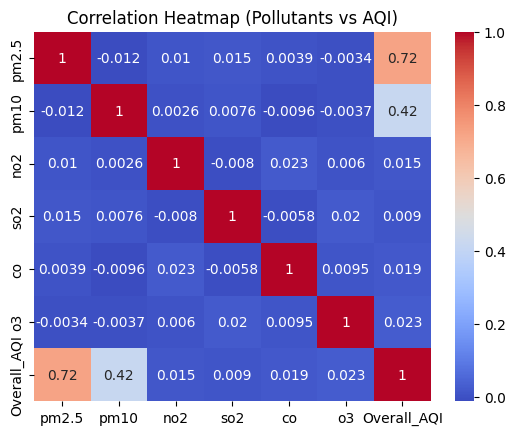

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['pm2.5','pm10','no2','so2','co','o3','Overall_AQI']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Pollutants vs AQI)")
plt.show()


In [ ]:
city_means = df.groupby('city')[['pm2.5','pm10','no2','so2','co','o3']].mean()
print(city_means)


                pm2.5        pm10        no2        so2        co          o3
city                                                                         
Bangalore  248.701149  296.130706  76.904269  50.402299  4.972879  100.160974
Chennai    253.083963  293.749754  76.200055  49.904762  4.936130   98.807882
Delhi      253.390914  293.526437  74.895402  50.100383  4.959748  101.419814
Kolkata    251.426437  302.127805  75.482923  48.889272  5.040936  101.998960
Mumbai     251.397920  303.122441  76.216147  50.516147  4.889026  100.833114


In [ ]:
city_avg = df.groupby('city')['Overall_AQI'].mean().sort_values(ascending=False)
print(city_avg)

city
Mumbai       400.237805
Delhi        399.252666
Chennai      398.627006
Kolkata      398.526535
Bangalore    396.576924
Name: Overall_AQI, dtype: float64
